# covert cat to region file

In [1]:
import pandas as pd

# ============================================================
# FILE PATHS
# ============================================================
input_file = "/Users/aishwarya/Desktop/CSV/Final_sources.csv"
output_file = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

# ============================================================
# READ CSV
# ============================================================
df = pd.read_csv(input_file)

# ============================================================
# KEEP ONLY RA, DEC
# ============================================================
df_clean = df[["ra", "dec"]]

# ============================================================
# SAVE AS TEXT (space-separated)
# ============================================================
df_clean.to_csv(output_file, sep=' ', index=False, header=False)

print(f"Saved file: {output_file}")

Saved file: /Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt


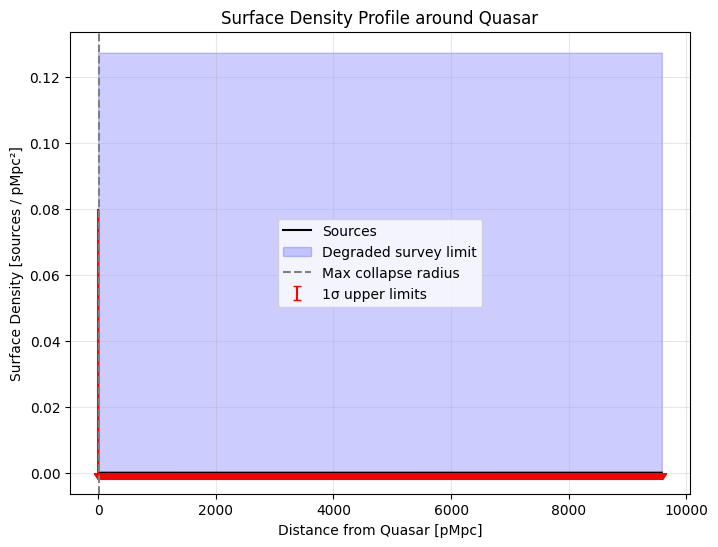

In [3]:
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Load source data
# ----------------------------
file_path = '/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt'

# Read file (assuming columns: RA [deg], Dec [deg])
data = np.loadtxt(file_path)
ra_sources = data[:,0]
dec_sources = data[:,1]

# Convert to SkyCoord objects
sources = SkyCoord(ra=ra_sources*u.deg, dec=dec_sources*u.deg)

# ----------------------------
# Step 2: Add quasar
# ----------------------------
quasar = SkyCoord('23h48m33.33s', '+30d54m10.23s', frame='icrs')

# Combine quasar with sources
all_coords = SkyCoord(ra=np.append(ra_sources, quasar.ra.deg)*u.deg,
                      dec=np.append(dec_sources, quasar.dec.deg)*u.deg)

# ----------------------------
# Step 3: Compute distances
# ----------------------------
# Angular separation in degrees
separations = all_coords.separation(quasar)

# Convert to comoving distance in pMpc (assuming quasar at z ~ 2)
z_quasar = 6.9 # change this to your actual quasar redshift
separations_mpc = separations.to(u.rad).value * cosmo.comoving_distance(z_quasar).value  # Mpc

# ----------------------------
# Step 4: Bin the data
# ----------------------------
bin_width = 2  # pMpc
bins = np.arange(0, np.max(separations_mpc)+bin_width, bin_width)
hist, bin_edges = np.histogram(separations_mpc, bins=bins)

# Surface density = N / area of annulus
bin_area = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)
surface_density = hist / bin_area

# 1 sigma Poisson upper limits
upper_limits = hist + np.sqrt(hist)
surface_density_upper = upper_limits / bin_area

# Bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:])/2

# ----------------------------
# Step 5: Plot
# ----------------------------
plt.figure(figsize=(8,6))

# Surface density profile
plt.step(bin_centers, surface_density, where='mid', color='black', label='Sources')

# Red arrows = 1σ upper limits
plt.errorbar(bin_centers, surface_density, 
             yerr=(surface_density_upper-surface_density), 
             fmt='none', ecolor='red', uplims=True, label='1σ upper limits')

# Blue shaded region (example: replace with actual degraded survey)
avg_upper_limit = np.max(surface_density_upper) * 0.8  # dummy value
plt.fill_between(bin_centers, 0, avg_upper_limit, color='blue', alpha=0.2, label='Degraded survey limit')

# Dashed line = maximum theoretical collapse radius
collapse_radius = 10  # pMpc, example from Overzier et al. 2009
plt.axvline(collapse_radius, color='gray', linestyle='--', label='Max collapse radius')

plt.xlabel('Distance from Quasar [pMpc]')
plt.ylabel('Surface Density [sources / pMpc²]')
plt.title('Surface Density Profile around Quasar')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

# ----------------------------
# USER INPUTS
# ----------------------------
file_sources = '/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt'
file_cdfs    = '/Users/aishwarya/Desktop/source_cdfs_true.txt'

z_quasar = 6.9
bin_width = 2.0  # pMpc

# Quasar position
quasar = SkyCoord('23h48m33.33s', '+30d54m10.23s', frame='icrs')

# ----------------------------
# STEP 1: LOAD DATA
# ----------------------------
data = np.loadtxt(file_sources)
ra_sources = data[:, 0]
dec_sources = data[:, 1]

sources = SkyCoord(ra=ra_sources * u.deg, dec=dec_sources * u.deg)

cdfs_data = np.loadtxt(file_cdfs)
ra_cdfs = cdfs_data[:, 0]
dec_cdfs = cdfs_data[:, 1]

cdfs_coords = SkyCoord(ra=ra_cdfs * u.deg, dec=dec_cdfs * u.deg)

# ----------------------------
# STEP 2: DISTANCES (FIXED)
# ----------------------------
# Proper distance (pMpc)
D_A = cosmo.angular_diameter_distance(z_quasar).to(u.Mpc).value

sep_sources = sources.separation(quasar)
sep_cdfs = cdfs_coords.separation(quasar)

# Convert to radians
theta_sources = sep_sources.to(u.radian).value
theta_cdfs = sep_cdfs.to(u.radian).value

# Projected distance
r_sources = theta_sources * D_A
r_cdfs = theta_cdfs * D_A

# ----------------------------
# REMOVE QUASAR + BAD VALUES
# ----------------------------
# Remove anything too close (quasar or duplicate)
r_sources = r_sources[r_sources > 0.05]
r_cdfs = r_cdfs[r_cdfs > 0.05]

# Remove extreme outliers (bad coordinates)
r_sources = r_sources[r_sources < 50]
r_cdfs = r_cdfs[r_cdfs < 50]

# ----------------------------
# SANITY CHECK
# ----------------------------
print("Max radius (sources):", np.max(r_sources))
print("Max radius (CDFS):", np.max(r_cdfs))

# ----------------------------
# STEP 3: BINNING (FIXED SCALE)
# ----------------------------
r_max = 20  # enforce physical scale like paper
bins = np.arange(0, r_max + bin_width, bin_width)

hist, edges = np.histogram(r_sources, bins=bins)
hist_cdfs, _ = np.histogram(r_cdfs, bins=bins)

# Annulus area
area = np.pi * (edges[1:]**2 - edges[:-1]**2)

# Surface densities
sigma_qso = hist / area
sigma_cdfs = hist_cdfs / area

# Poisson errors
sigma_qso_err = np.sqrt(hist) / area
sigma_cdfs_err = np.sqrt(hist_cdfs) / area

# Upper limits
sigma_qso_upper = (hist + np.sqrt(hist)) / area
sigma_cdfs_upper = (hist_cdfs + np.sqrt(hist_cdfs)) / area

# Bin centers
r_centers = 0.5 * (edges[:-1] + edges[1:])

# ----------------------------
# STEP 4: OVERDENSITY
# ----------------------------
overdensity = np.full_like(sigma_qso, np.nan)
overdensity_err = np.full_like(sigma_qso, np.nan)

valid = (sigma_cdfs > 0) & (sigma_qso > 0)

overdensity[valid] = (
    sigma_qso[valid] - sigma_cdfs[valid]
) / sigma_cdfs[valid]

# Error propagation
overdensity_err[valid] = np.sqrt(
    (sigma_qso_err[valid] / sigma_cdfs[valid])**2 +
    (sigma_qso[valid] * sigma_cdfs_err[valid] / sigma_cdfs[valid]**2)**2
)

# ----------------------------
# STEP 5: PLOTTING
# ----------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10), sharex=True)

# ===== TOP: Surface Density =====
ax1.step(r_centers, sigma_qso, where='mid', color='black', label='Quasar field')

# Detections
mask = hist > 0
ax1.errorbar(r_centers[mask], sigma_qso[mask],
             yerr=sigma_qso_err[mask],
             fmt='o', color='black')

# Upper limits
mask_zero = hist == 0
ax1.errorbar(r_centers[mask_zero], sigma_qso_upper[mask_zero],
             fmt='v', color='red', uplims=True, label='1σ upper limits')

# CDFS shaded region
ax1.fill_between(r_centers, 0, sigma_cdfs_upper,
                 color='blue', alpha=0.2, label='CDFS upper limit')

# Collapse radius
collapse_radius = 10
ax1.axvline(collapse_radius, linestyle='--', color='gray')

ax1.set_yscale('log')
ax1.set_ylabel('Surface Density [sources / pMpc²]')
ax1.set_title('Surface Density Profile')
ax1.legend()
ax1.grid(alpha=0.3)

# ===== BOTTOM: Overdensity =====
ax2.errorbar(r_centers[valid],
             overdensity[valid],
             yerr=overdensity_err[valid],
             fmt='o', color='black')

ax2.axhline(0, linestyle='--', color='gray')
ax2.axvline(collapse_radius, linestyle='--', color='gray')

ax2.set_xlabel('Distance from Quasar [pMpc]')
ax2.set_ylabel('Overdensity δ')
ax2.set_title('Overdensity Profile')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation maximum which has no identity

# Mark on the file

In [4]:
# ----------------------------
# LOAD SOURCES + CONVERT TO ICRS
# ----------------------------
cat = np.loadtxt(catalog_file)

ra = cat[:, 0]
dec = cat[:, 1]

# Create SkyCoord (ICRS)
sources = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs')

# ----------------------------
# PRINT FIRST FEW COORDS
# ----------------------------
print("\nFirst 5 sources (degrees):")
for i in range(5):
    print(f"{i}: RA = {sources.ra.deg[i]:.6f}, Dec = {sources.dec.deg[i]:.6f}")

print("\nFirst 5 sources (sexagesimal):")
for i in range(5):
    print(f"{i}: {sources[i].to_string('hmsdms')}")


First 5 sources (degrees):
0: RA = 358.193029, Dec = -30.942987
1: RA = 357.459842, Dec = -31.629391
2: RA = 357.278628, Dec = -31.660727
3: RA = 356.413992, Dec = -31.564850
4: RA = 356.170926, Dec = -31.317514

First 5 sources (sexagesimal):
0: 23h52m46.32696s -30d56m34.75392s
1: 23h49m50.362008s -31d37m45.80868s
2: 23h49m06.8706s -31d39m38.61756s
3: 23h45m39.358056s -31d33m53.46s
4: 23h44m41.022192s -31d19m03.05184s


Closest source distance (arcsec): 0.12523081455437446
Removed: 1


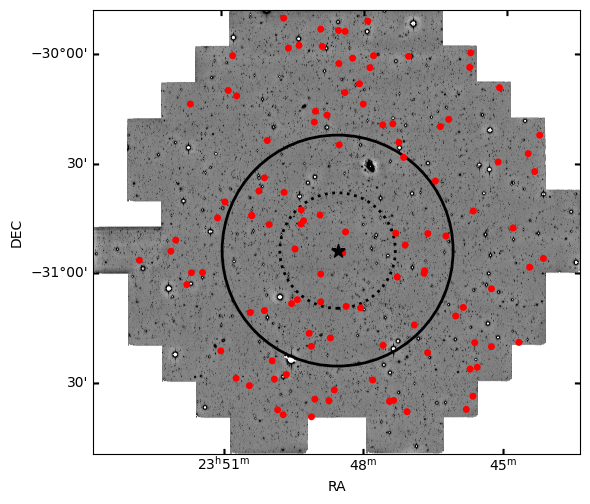

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import ZScaleInterval
from regions import Regions

# ----------------------------
# FILES
# ----------------------------
IMG_FILE = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Mosaic/mosaic_Y.fits"
WT_FILE  = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Mosaic/mosaic_Y_weight.fits"
REG_FILE = "/Users/aishwarya/Desktop/DECAM.reg"
CAT_FILE = "/Users/aishwarya/Desktop/CSV/Final_sources_ra_dec.txt"

# ----------------------------
# COSMOLOGY
# ----------------------------
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
z = 6.9
arcsec_per_kpc = COSMO.arcsec_per_kpc_proper(z)

def mpc_to_deg(mpc):
    return (mpc * 1000 * u.kpc * arcsec_per_kpc).to(u.deg).value

# ----------------------------
# QUASAR
# ----------------------------
quasar = SkyCoord(ra=357.138875*u.deg,
                  dec=-30.9028417*u.deg)

# ----------------------------
# LOAD IMAGE
# ----------------------------
img_hdul = fits.open(IMG_FILE, memmap=True)
data = img_hdul[0].data.astype(np.float32)
wcs = WCS(img_hdul[0].header)

# ----------------------------
# LOAD WEIGHT → FOOTPRINT MASK
# ----------------------------
wt = fits.open(WT_FILE)[0].data.astype(np.float32)

threshold = 0.003
mask = (wt > threshold) & np.isfinite(wt)

data_plot = data.copy()
data_plot[~mask] = np.nan   # outside footprint = white

# ----------------------------
# LOAD REGION (DECam footprint)
# ----------------------------
regions = Regions.read(REG_FILE, format='ds9')


# ----------------------------
# LOAD SOURCES + REMOVE QSO
# ----------------------------
cat = np.loadtxt(CAT_FILE)

sources_all = SkyCoord(ra=cat[:,0]*u.deg,
                       dec=cat[:,1]*u.deg)

# Compute separation
sep = sources_all.separation(quasar)

# Remove anything within 3 arcsec of QSO
mask_not_qso = sep > 1 * u.arcsec

sources = sources_all[mask_not_qso]

# Convert to pixel AFTER filtering
x_src, y_src = wcs.world_to_pixel(sources)
x_qso, y_qso = wcs.world_to_pixel(quasar)

# Debug check
print("Closest source distance (arcsec):", np.min(sep.arcsec))
print("Removed:", np.sum(~mask_not_qso))
# ----------------------------
# RADII
# ----------------------------
r5 = mpc_to_deg(5)
r10 = mpc_to_deg(10)

# convert to pixels
pixel_scale = np.abs(wcs.pixel_scale_matrix[1,1])  # deg/pixel
r5_pix = r5 / pixel_scale
r10_pix = r10 / pixel_scale

# ----------------------------
# IMAGE SCALING (paper style)
# ----------------------------
zscale = ZScaleInterval()
vmin, vmax = zscale.get_limits(data_plot)

# ----------------------------
# PLOT
# ----------------------------
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=wcs)

ax.set_facecolor('white')

# image
ax.imshow(data_plot,
          origin='lower',
          cmap='gray_r',
          vmin=vmin,
          vmax=vmax)

# ----------------------------
# FOOTPRINT (exact DS9 region)
# ----------------------------
for reg in regions:
    pix_reg = reg.to_pixel(wcs)
    pix_reg.plot(ax=ax, color='black', lw=2)

# ----------------------------
# RINGS
# ----------------------------
circle_outer = plt.Circle((x_qso, y_qso),
                          r10_pix,
                          color='black',
                          fill=False,
                          linewidth=2)

circle_inner = plt.Circle((x_qso, y_qso),
                          r5_pix,
                          color='black',
                          fill=False,
                          linestyle=':',
                          linewidth=2)

# central shaded region
circle_core = plt.Circle((x_qso, y_qso),
                         r5_pix*0.35,
                         color='gray',
                         alpha=0.3)

ax.add_patch(circle_core)
ax.add_patch(circle_outer)
ax.add_patch(circle_inner)

# ----------------------------
# SOURCES
# ----------------------------
ax.scatter(x_src, y_src,
           s=25,
           color='red',
           edgecolors='none',
           zorder=5)

# quasar
ax.scatter(x_qso, y_qso,
           marker='*',
           s=100,
           color='black',
           zorder=6)

# ----------------------------
# AXES STYLE (paper-like)
# ----------------------------
ax.set_xlabel("RA")
ax.set_ylabel("DEC")

ax.coords[0].set_major_formatter('hh:mm')
ax.coords[1].set_major_formatter('dd:mm')

ax.minorticks_on()
ax.tick_params(which='both', direction='in', width=1.2)
ax.tick_params(which='major', length=4)

ax.grid(False)

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from astropy.io import fits

# ----------------------------
# FILES
# ----------------------------
SCI_FILE = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/c4d_240921_233618_osj_Y_v2.fits.fz"
WHT_FILE = "/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/c4d_240921_233618_osw_Y_v2.fits.fz"

# ----------------------------
# LOAD FILES
# ----------------------------
sci = fits.open(SCI_FILE)
wht = fits.open(WHT_FILE)

# ----------------------------
# PARAMETERS
# ----------------------------
ZP = 30.0   # <-- change this to your image zeropoint!
N_SIGMA = 5

depths = []

print("CCD   MedianSigma   5σ Depth (mag)")

for i in range(1, len(sci)):

    weight = wht[i].data

    if weight is None:
        continue

    # Mask bad pixels
    good = (weight > 0) & np.isfinite(weight)

    if np.sum(good) < 100:
        continue

    # Convert weight → sigma
    sigma = 1.0 / np.sqrt(weight[good])

    # Use median noise (robust)
    sigma_med = np.median(sigma)

    # 5-sigma flux
    flux_5sigma = N_SIGMA * sigma_med

    # Convert to magnitude
    mag_5sigma = ZP - 2.5 * np.log10(flux_5sigma)

    depths.append(mag_5sigma)

    print(f"{i:3d}   {sigma_med:.4e}   {mag_5sigma:.2f}")

# ----------------------------
# SUMMARY
# ----------------------------
depths = np.array(depths)

print("\n--- SUMMARY ---")
print(f"Mean depth: {np.mean(depths):.2f}")
print(f"Std dev:    {np.std(depths):.2f}")
print(f"Min depth:  {np.min(depths):.2f}")
print(f"Max depth:  {np.max(depths):.2f}")

CCD   MedianSigma   5σ Depth (mag)
  1   1.6193e+01   25.23
  2   1.5945e+01   25.25
  3   1.6026e+01   25.24
  4   1.5840e+01   25.25
  5   1.5954e+01   25.25
  6   1.5939e+01   25.25
  7   1.5934e+01   25.25
  8   1.5844e+01   25.25
  9   1.6238e+01   25.23

--- SUMMARY ---
Mean depth: 25.24
Std dev:    0.01
Min depth:  25.23
Max depth:  25.25


In [6]:
print(np.median(wht[1].data))

1.1173059e-06


In [ ]:
print("\nRanges:")
print("RA:", ra.min(), ra.max())
print("Dec:", dec.min(), dec.max())

print("\nQuasar:")
print(quasar.ra.deg, quasar.dec.deg)

In [4]:
sep_arcsec = sources.separation(quasar).arcsec

idx = np.argmin(sep_arcsec)

print("Closest object:")
print("Distance (arcsec):", sep_arcsec[idx])
print("RA:", sources[idx].ra.deg)
print("DEC:", sources[idx].dec.deg)

Closest object:
Distance (arcsec): 91.9926816124359
RA: 357.1118695
DEC: -30.9136172
